In [26]:
import sys
sys.path.insert(0,"../.")
from cogwheel import prior_ratio
prior_ratio.__file__
import numpy as np

from cogwheel.gw_prior.combined import IASPrior, LVCPrior
from cogwheel.gw_plotting import MultiCornerPlot
from cogwheel.utils import exp_normalize


In [6]:
init_dict = {'f_ref': 50.0,
 'mchirp_range': np.array([16.35294111, 42.3981393 ]),
 'q_min': np.float64(0.05000000000000001),
 'symmetrize_lnq': np.False_,
 'detector_pair': 'LH',
 'tgps': 1381291551.0,
 't0_refdet': np.float64(-0.01453418656769051),
 'dt0': np.float64(0.07),
 'ref_det_name': 'L',
 'f_avg': 112.0,
 'par_dic_0': {'d_luminosity': 590.8233395959464,
  'dec': 0.8759750622542973,
  'f_ref': 50.0,
  'iota': 1.0,
  'l1': 0.0,
  'l2': 0.0,
  'm1': 31.317169748262412,
  'm2': 20.878113165508275,
  'phi_ref': 0.23633204732571386,
  'psi': 0.0,
  'ra': 2.6000111546500975,
  's1x_n': 0.0,
  's1y_n': 0.0,
  's1z': 0.2668435091242674,
  's2x_n': 0.0,
  's2y_n': 0.0,
  's2z': 0.2668435091242674,
  't_geocenter': -0.016988612097411173},
 'd_hat_max': np.float64(500.0),
 'd_luminosity_max': np.inf}

ias_prior = IASPrior(**init_dict)
lvc_prior = LVCPrior(**init_dict)

ias_prior_samples = ias_prior.generate_random_samples(10000)
lvc_prior_samples = lvc_prior.generate_random_samples(10000)


In [27]:
pr = prior_ratio.PriorRatio(numerator=lvc_prior, denominator=ias_prior)
ias_prior_samples["log_weights"] = ias_prior_samples.apply(lambda row: pr.ln_prior_ratio(**row.to_dict()), axis=1)
ias_prior_samples["weights"] = exp_normalize(ias_prior_samples["log_weights"].values)


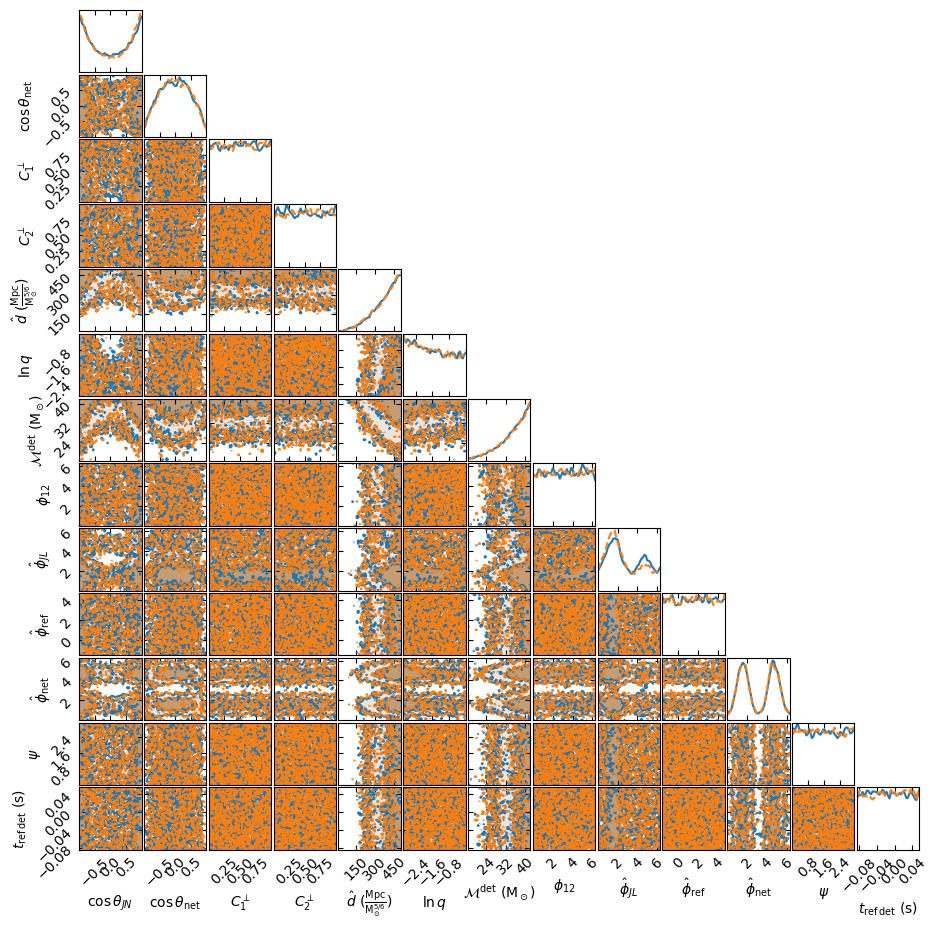

In [35]:
params = set(ias_prior.sampled_params).intersection(lvc_prior.sampled_params)

params = sorted([p for p in params if ias_prior_samples[p].std() > 1e-10])
MultiCornerPlot([ias_prior_samples, lvc_prior_samples], 
                params=params,weights_col=None).plot()

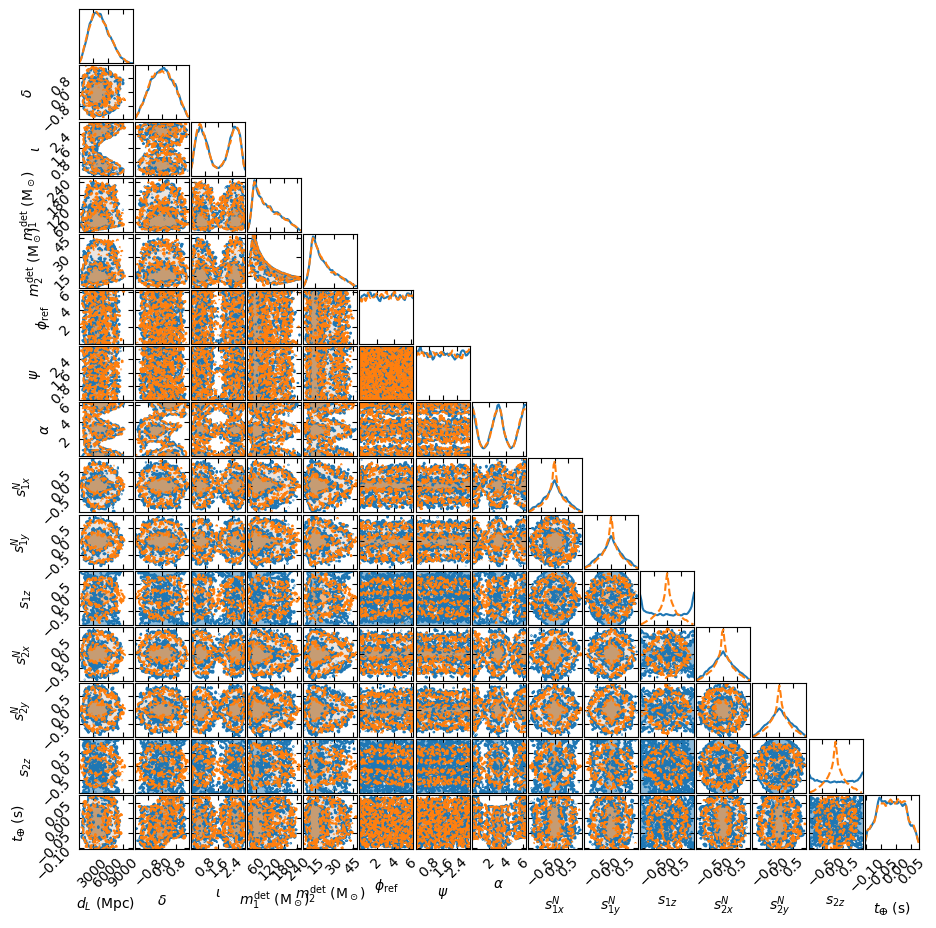

In [36]:
params = set(ias_prior.standard_params).intersection(lvc_prior.standard_params)
params = sorted([p for p in params if ias_prior_samples[p].std() > 1e-10])
MultiCornerPlot([ias_prior_samples, lvc_prior_samples], 
                params=params,weights_col=None).plot()

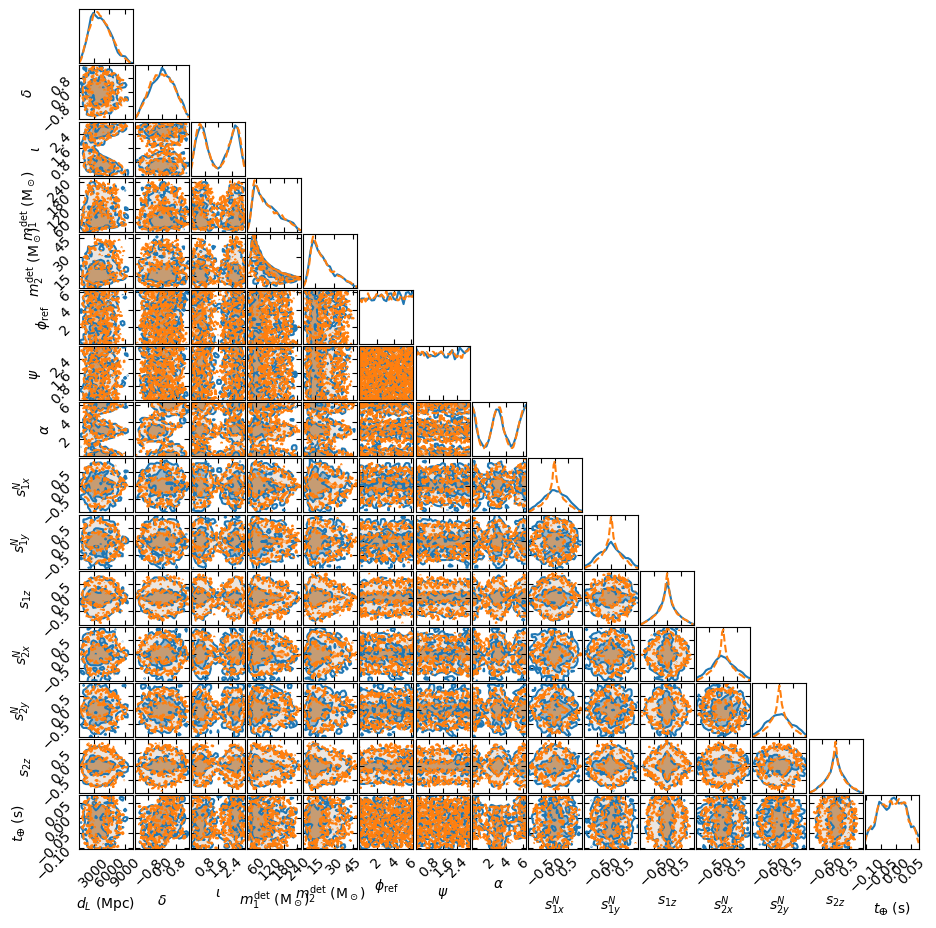

In [40]:
params = set(ias_prior.standard_params).intersection(lvc_prior.standard_params)
params = sorted([p for p in params if ias_prior_samples[p].std() > 1e-10])
MultiCornerPlot([ias_prior_samples, lvc_prior_samples], 
                params=params,weights_col="weights").plot()

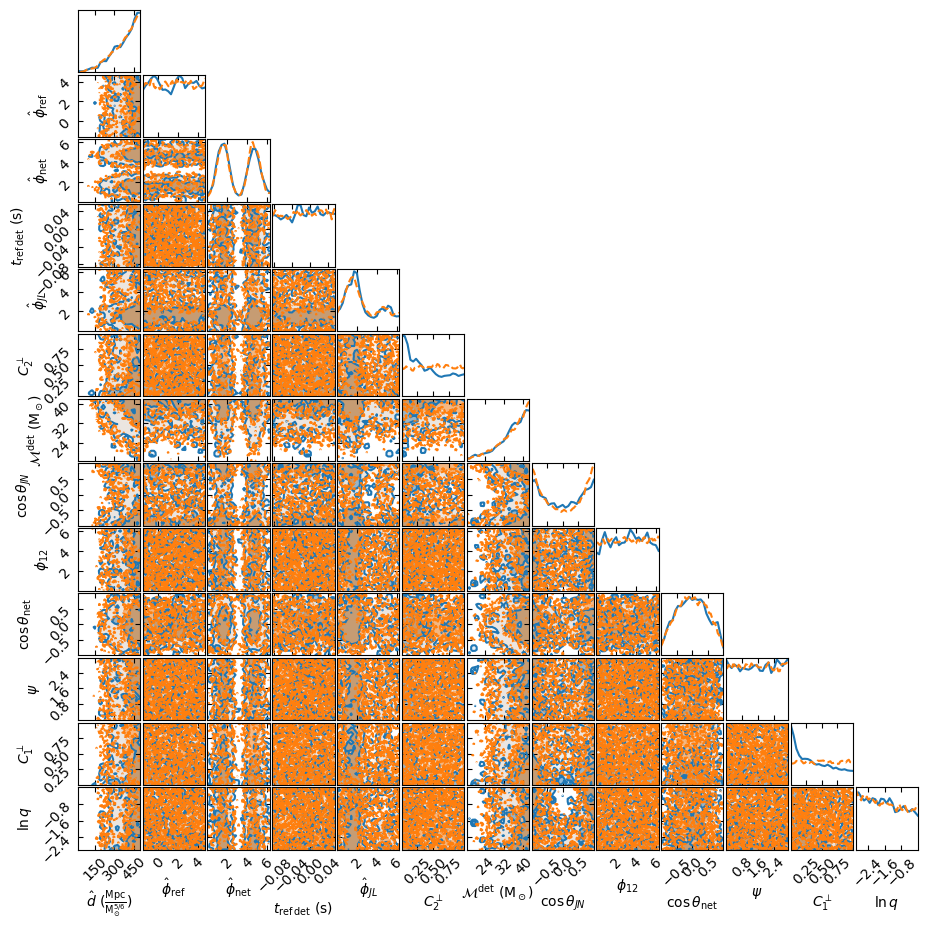

In [41]:
params = list(set(ias_prior.sampled_params).intersection(lvc_prior.sampled_params))

MultiCornerPlot([ias_prior_samples, lvc_prior_samples], 
                params=params,weights_col="weights").plot()